In [ ]:
import sys
import os
project_root=r"your_path\Project"
sys.path.insert(0, project_root)
sys.path.append(r"your_path\Project\models")
sys.path.append(r"your_path\Project\utils")
sys.path.append(r"your_path\Project\dataset")

import json
import torch
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from config import *
from dataset import BSD500Dataset, create_dataloaders
from evaluator import evaluate_model
from metrics import measure_inference_time
from shallow_autoencoder import ShallowAutoencoder
from deep_autoencoder import DeepAutoencoder
from residual_autoencoder import ResidualAutoencoder
from visualization import (
    plot_training_curves,
    plot_validation_curves,
    show_denoising_results,
    plot_error_maps,
)


In [2]:
test_dataset = BSD500Dataset(
    image_dir=TEST_DIR,
    patch_size=PATCH_SIZE,
    patches_per_image=PATCHES_PER_IMAGE,
    add_noise=True
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

In [3]:
shallow_model = ShallowAutoencoder().to(DEVICE)

shallow_model.load_state_dict(
    torch.load(
        MODELS_DIR / "shallow_mse_best.pth",
        map_location=DEVICE,
    )
)

<All keys matched successfully>

In [4]:
deep_model = DeepAutoencoder().to(DEVICE)

deep_model.load_state_dict(
    torch.load(
        MODELS_DIR / "deep_mse_best.pth",
        map_location=DEVICE,
    )
)

<All keys matched successfully>

In [5]:
residual_mse_model = ResidualAutoencoder().to(DEVICE)

residual_mse_model.load_state_dict(
    torch.load(
        MODELS_DIR / "residual_mse_best.pth",
        map_location=DEVICE,
    )
)

<All keys matched successfully>

In [6]:
residual_hybrid_model = ResidualAutoencoder().to(DEVICE)

residual_hybrid_model.load_state_dict(
    torch.load(
        MODELS_DIR / "residual_hybrid_best.pth",
        map_location=DEVICE,
    )
)

<All keys matched successfully>

In [7]:
shallow_model.eval()

ShallowAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bottleneck): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (5): ReLU(inplace=True)
    (6): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(32

In [8]:
deep_model.eval()

DeepAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bottleneck): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2

In [9]:
residual_mse_model.eval()

ResidualAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (relu): ReLU(inplace=True)
    )
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (relu): ReLU(inplace=True)
    )
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
 

In [10]:
residual_hybrid_model.eval()

ResidualAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (relu): ReLU(inplace=True)
    )
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (relu): ReLU(inplace=True)
    )
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
 

In [11]:
models= {
    "shallow AE" : shallow_model,
    "Deep AE" : deep_model,
    "Residual AE" : residual_mse_model,
    "Residual AE hybrid" : residual_hybrid_model,
}
print(models)

{'shallow AE': ShallowAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bottleneck): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (5): ReLU(inplace=True)
    (6): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
   

In [12]:
results={}

for name, model in models.items():
    print(f"Evaluating {name}...")
    results[name] = evaluate_model(
        model=model,
        dataloader=test_loader,
        device=DEVICE,
    )
    print(f"{name}: {results[name]}")  

Evaluating shallow AE...
shallow AE: {'PSNR': 25.384980072021484, 'SSIM': 0.7339990310668946, 'Parameters': 181347}
Evaluating Deep AE...
Deep AE: {'PSNR': 25.81463900756836, 'SSIM': 0.7552789268493653, 'Parameters': 273699}
Evaluating Residual AE...
Residual AE: {'PSNR': 26.533558868408203, 'SSIM': 0.7884695043563843, 'Parameters': 615043}
Evaluating Residual AE hybrid...
Residual AE hybrid: {'PSNR': 25.803927795410157, 'SSIM': 0.840449899673462, 'Parameters': 615043}


In [13]:
shallow_metrics = evaluate_model(
    shallow_model,
    test_loader,
)

deep_metrics = evaluate_model(
    deep_model,
    test_loader,
)

residual_mse_metrics = evaluate_model(
    residual_mse_model,
    test_loader,
)

residual_hybrid_metrics = evaluate_model(
    residual_hybrid_model,
    test_loader,
)

In [14]:
sample_noisy, _ = test_dataset[0]

sample_noisy = sample_noisy.unsqueeze(0)

In [15]:
shallow_time = measure_inference_time(
    shallow_model,
    sample_noisy,
)

deep_time = measure_inference_time(
    deep_model,
    sample_noisy,
)


residual_mse_time = measure_inference_time(
    residual_mse_model,
    sample_noisy,
)


residual_hybrid_time = measure_inference_time(
    residual_hybrid_model,
    sample_noisy,
)

In [16]:
comparison_table = pd.DataFrame(
    {
        "Model": list(results.keys()),
        "PSNR (dB)": [
            results[name]["PSNR"]
            for name in results
        ],
        "SSIM": [
            results[name]["SSIM"]
            for name in results
        ],
        "Parameters": [
            results[name]["Parameters"]
            for name in results
        ],
       # "Inference Time (ms)": [
        #    results[name]["Inference_time"]
       #     for name in results
        #],
    }
)

In [17]:
architecture_results = pd.DataFrame([
    {
        "Model": "Shallow AE",
        **shallow_metrics,
        "Inference Time": shallow_time,
    },
    {
        "Model": "Deep AE",
        **deep_metrics,
        "Inference Time": deep_time,
    },
    {
        "Model": "Residual AE",
        **residual_mse_metrics,
        "Inference Time": residual_mse_time,
    },
])

architecture_results

,Model,PSNR,SSIM,Parameters,Inference Time
0,Shallow AE,25.297285,0.732561,181347,0.010383
1,Deep AE,25.757184,0.757179,273699,0.001287
2,Residual AE,26.505352,0.787235,615043,0.010962


In [18]:
loss_results = pd.DataFrame([
    {
        "Loss": "MSE",
        "PSNR": residual_mse_metrics["PSNR"],
        "SSIM": residual_mse_metrics["SSIM"],
    },
    {
        "Loss": "Hybrid",
        "PSNR": residual_hybrid_metrics["PSNR"],
        "SSIM": residual_hybrid_metrics["SSIM"],
    },
])

loss_results

,Loss,PSNR,SSIM
0,MSE,26.505352,0.787235
1,Hybrid,25.796278,0.840983


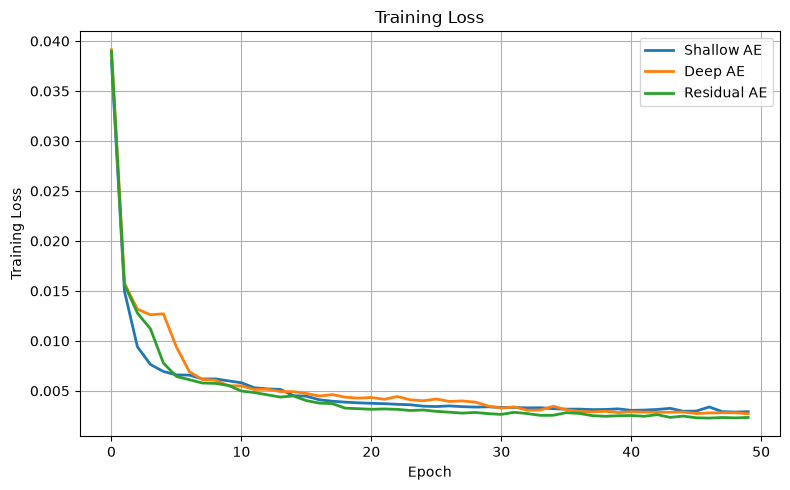

In [19]:
from visualization import plot_training_curves

with open(HISTORY_DIR / "shallow_mse_history.json", "r") as f:
    shallow_history = json.load(f)

with open(HISTORY_DIR / "deep_mse_history.json", "r") as f:
    deep_history = json.load(f)

with open(HISTORY_DIR / "residual_mse_history.json", "r") as f:
    residual_mse_history = json.load(f)

plot_training_curves(
    histories=[
        shallow_history,
        deep_history,
        residual_mse_history,
    ],
    labels=[
        "Shallow AE",
        "Deep AE",
        "Residual AE",
    ],
    save_path= PLOTS_DIR/"training_loss.png",
)

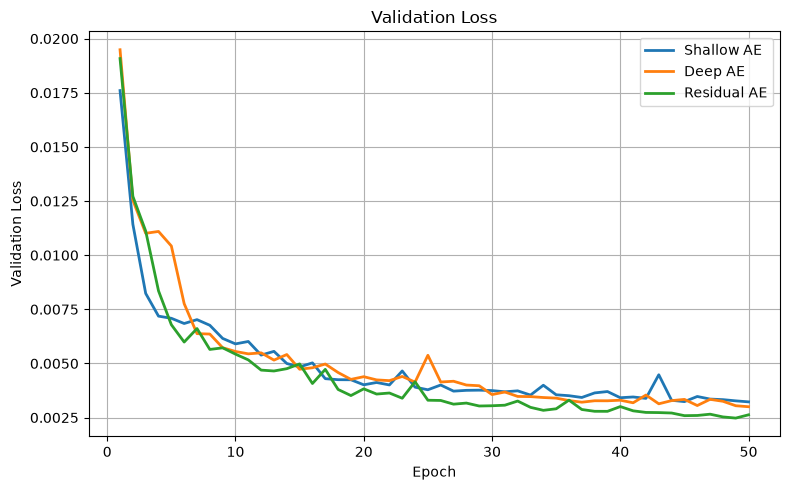

In [20]:
from visualization import plot_validation_curves

with open(HISTORY_DIR / "shallow_mse_history.json", "r") as f:
    shallow_history = json.load(f)

with open(HISTORY_DIR / "deep_mse_history.json", "r") as f:
    deep_history = json.load(f)

with open(HISTORY_DIR / "residual_mse_history.json", "r") as f:
    residual_mse_history = json.load(f)

plot_validation_curves(
    histories=[
        shallow_history,
        deep_history,
        residual_mse_history,
    ],
    labels=[
        "Shallow AE",
        "Deep AE",
        "Residual AE",
    ],
    save_path= PLOTS_DIR/"validation_loss.png",
)

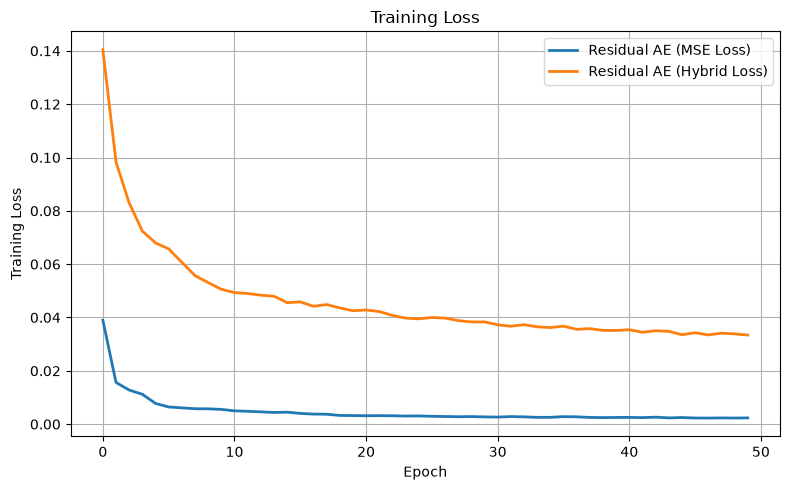

In [21]:
# Load hybrid loss history
with open(HISTORY_DIR / "residual_hybrid_history.json", "r") as f:
    residual_hybrid_history = json.load(f)

# Compare MSE vs Hybrid for Residual AE
plot_training_curves(
    histories=[
        residual_mse_history,
        residual_hybrid_history,
    ],
    labels=[
        "Residual AE (MSE Loss)",
        "Residual AE (Hybrid Loss)",
    ],
    save_path=PLOTS_DIR / "residual_loss_comparison.png",
)

In [23]:
noisy_image, clean_image = test_dataset[0]
clean_input = clean_image.unsqueeze(0).to(DEVICE)
noisy_input = noisy_image.unsqueeze(0).to(DEVICE)

In [24]:
with torch.no_grad():

    shallow_prediction = shallow_model(noisy_input)

    deep_prediction = deep_model(noisy_input)

    residual_prediction = residual_mse_model(noisy_input)

    hybrid_prediction = residual_hybrid_model(noisy_input)

shallow_prediction = shallow_prediction.squeeze(0)

deep_prediction = deep_prediction.squeeze(0)

residual_prediction = residual_prediction.squeeze(0)

hybrid_prediction = hybrid_prediction.squeeze(0)


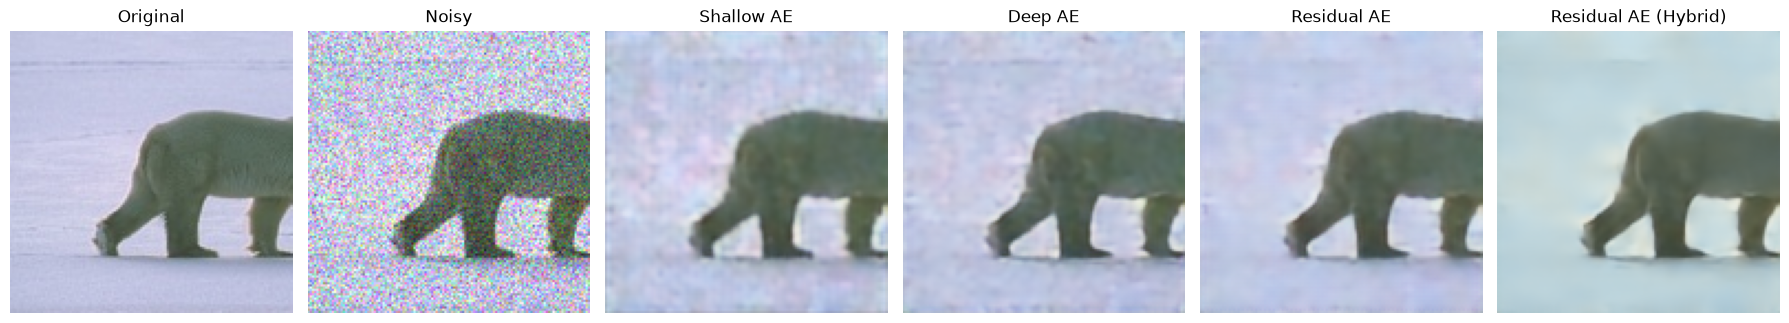

In [25]:
show_denoising_results(
    clean_image=clean_image,
    noisy_image=noisy_image,
    predictions=[
        shallow_prediction,
        deep_prediction,
        residual_prediction,
        hybrid_prediction,
    ],
    prediction_titles=[
        "Shallow AE",
        "Deep AE",
        "Residual AE",
        "Residual AE (Hybrid)",
    ],
    save_path=PLOTS_DIR / "denoising_comparison.png",
)

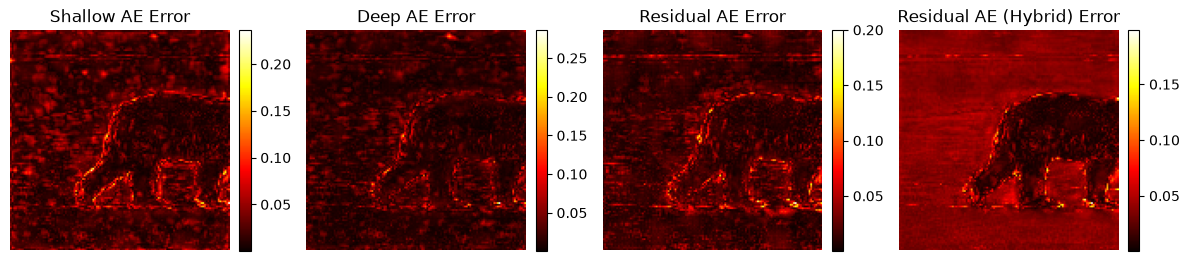

In [26]:
plot_error_maps(
    clean_image=clean_image,
    predictions=[
        shallow_prediction,
        deep_prediction,
        residual_prediction,
        hybrid_prediction,
    ],
    prediction_titles=[
        "Shallow AE",
        "Deep AE",
        "Residual AE",
        "Residual AE (Hybrid)",
    ],
    save_path=PLOTS_DIR / "error_maps.png",
)